# 01 - Data Cleaning

**Objective:** Load the raw basketball dataset, handle missing values, remove duplicates, and treat outliers.

**Pipeline:**
1. Load & inspect raw data
2. Handle missing values (median imputation)
3. Remove duplicates
4. Outlier treatment (IQR clipping)
5. Save cleaned dataset

**Note:** Feature engineering is performed separately in notebook 04, after EDA and hypothesis testing inform our feature design decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load & Inspect Raw Data

In [2]:
# load the data
df = pd.read_csv("../data/raw/11_Baseketball_Team_Performance_Analysis.csv")
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")
df.head()

Dataset shape: (10000, 37)
Rows: 10,000, Columns: 37


,id,year,rank,school,games,wins,losses,win_percentage,conference_wins,conference_losses,...,offensive_rebounds,total_rebounds,assists,steals,blocks,turnovers,personal_fouls,points,opponent_points,simple_rating
0,1,2021,1,Villanova,38,30,8,0.789,16,4,...,10.3,34.8,11.9,6.0,2.2,9.9,14.9,71.7,62.7,19.31
1,2,2021,2,Providence,33,27,6,0.818,14,3,...,10.5,37.6,13.2,5.0,3.7,11.4,16.0,71.5,66.2,13.08
2,3,2021,3,UConn,33,23,10,0.697,13,6,...,13.8,40.4,14.0,5.9,6.4,11.8,16.8,74.8,65.3,16.40
3,4,2021,4,Creighton,35,23,12,0.657,12,7,...,9.6,38.1,13.3,5.5,4.3,14.1,13.6,69.2,66.4,11.34
4,5,2021,5,Marquette,32,19,13,0.594,11,8,...,7.8,34.8,16.0,7.8,5.2,12.4,17.4,74.0,71.6,11.36


In [3]:
# data types and memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id                               10000 non-null  int64  
 1   year                             10000 non-null  int64  
 2   rank                             10000 non-null  int64  
 3   school                           10000 non-null  str    
 4   games                            10000 non-null  int64  
 5   wins                             10000 non-null  int64  
 6   losses                           10000 non-null  int64  
 7   win_percentage                   10000 non-null  float64
 8   conference_wins                  10000 non-null  int64  
 9   conference_losses                10000 non-null  int64  
 10  home_wins                        9792 non-null   float64
 11  home_losses                      9792 non-null   float64
 12  away_wins                     

In [4]:
# statistical summary
df.describe().round(2)

,id,year,rank,games,wins,losses,win_percentage,conference_wins,conference_losses,home_wins,...,offensive_rebounds,total_rebounds,assists,steals,blocks,turnovers,personal_fouls,points,opponent_points,simple_rating
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0,10000.00,10000.00,10000.00,9792.00,...,9841.00,10000.00,9993.0,9984.00,9981.00,9980.00,9981.00,10000.00,10000.00,10000.00
mean,248.41,2000.02,8.37,31.37,20.43,13.6,0.60,8.55,9.94,11.06,...,12.32,36.38,14.8,8.01,4.84,14.27,19.05,72.79,68.62,11.14
std,144.14,12.40,4.64,6.11,9.06,6.8,0.19,5.14,5.39,4.96,...,2.71,4.13,2.9,2.15,2.03,2.87,3.16,6.64,6.02,5.89
min,1.00,1979.00,1.00,19.00,5.00,2.0,0.19,0.00,1.00,2.00,...,7.50,27.70,8.8,4.00,1.40,8.70,12.70,58.80,53.50,0.00
25%,123.00,1989.00,4.00,27.00,13.00,8.0,0.46,4.00,5.00,7.00,...,10.10,33.10,12.5,6.20,3.20,11.80,16.50,67.90,64.30,6.91
50%,248.00,2000.00,8.00,32.00,20.00,14.0,0.62,9.00,10.00,11.00,...,12.20,36.30,14.7,8.00,4.70,14.20,18.90,72.70,68.50,11.35
75%,374.00,2011.00,12.00,36.00,28.00,19.0,0.75,13.00,15.00,15.00,...,14.40,39.50,17.0,9.70,6.30,16.50,21.40,77.90,73.20,15.48
max,496.00,2021.00,16.00,41.00,36.00,25.0,0.94,17.00,19.00,19.00,...,18.60,45.50,20.8,13.10,9.10,20.90,28.40,89.70,83.00,26.64


## 2. Handle Missing Values

In [5]:
# check for missing values
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_df = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
print(null_df[null_df['Null Count'] > 0].sort_values('Null Count', ascending=False))
print(f"\nTotal cells with missing values: {df.isnull().sum().sum():,}")

                                 Null Count  Null %
offensive_rating                        278    2.78
net_rating                              278    2.78
defensive_rating                        278    2.78
home_wins                               208    2.08
home_losses                             208    2.08
away_losses                             208    2.08
away_wins                               208    2.08
offensive_rebounds                      159    1.59
3_pointers                               58    0.58
3_pointer_attempts                       58    0.58
3_pointer_percentage                     58    0.58
effective_field_goal_percentage          58    0.58
turnovers                                20    0.20
personal_fouls                           19    0.19
blocks                                   19    0.19
steals                                   16    0.16
assists                                   7    0.07

Total cells with missing values: 2,138


In [6]:
# fill missing values with median (robust to outliers)
df = df.fillna(df.median(numeric_only=True))
print("Nulls after filling:", df.isnull().sum().sum())

Nulls after filling: 0


## 3. Remove Duplicates

In [7]:
# check duplicates
print(f"Duplicates found: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after dedup: {df.shape}")

Duplicates found: 0
Shape after dedup: (10000, 37)


## 4. Outlier Treatment (IQR Method)

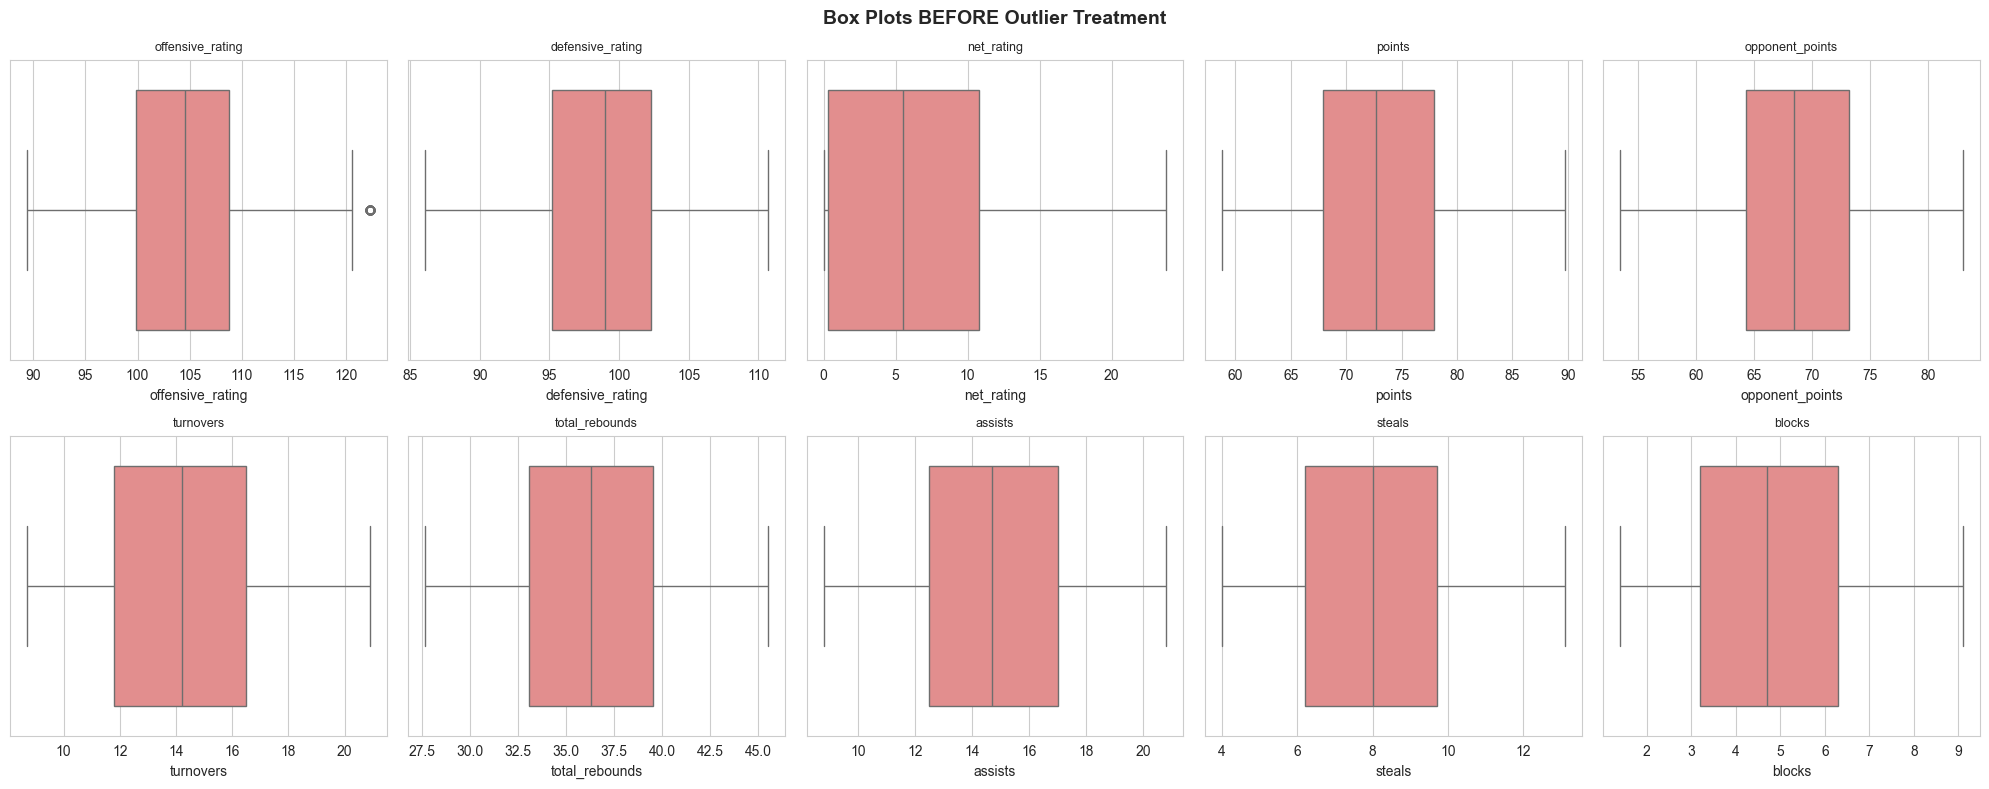

In [8]:
# visualize outliers for key metrics BEFORE treatment
cols_to_check = ['offensive_rating', 'defensive_rating', 'net_rating', 'points', 
                 'opponent_points', 'turnovers', 'total_rebounds', 'assists', 'steals', 'blocks']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Box Plots BEFORE Outlier Treatment', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cols_to_check):
    sns.boxplot(x=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

In [9]:
# remove outliers using IQR clipping
for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
    
print("Outlier clipping applied to:", cols_to_check)

Outlier clipping applied to: ['offensive_rating', 'defensive_rating', 'net_rating', 'points', 'opponent_points', 'turnovers', 'total_rebounds', 'assists', 'steals', 'blocks']


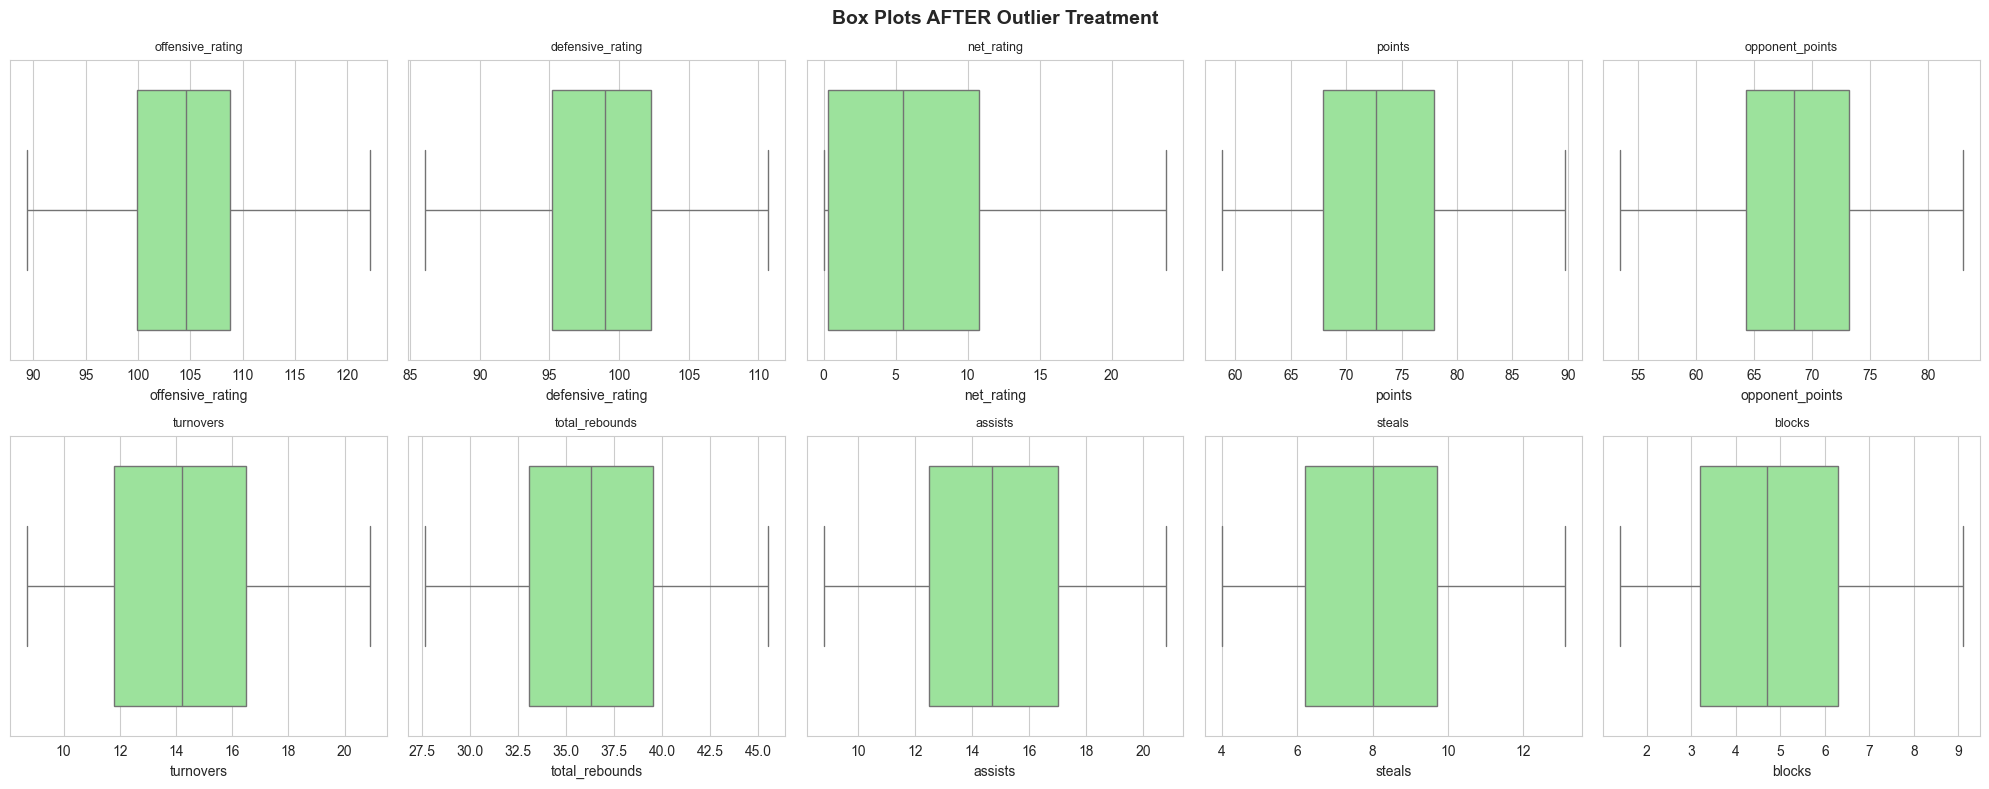

In [10]:
# verify - box plots AFTER treatment
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Box Plots AFTER Outlier Treatment', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cols_to_check):
    sns.boxplot(x=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

## 5. Save Cleaned Dataset

In [11]:
# save cleaned data (without engineered features - those come in notebook 04)
df.to_csv("../data/processed/cleaned_basketball_data.csv", index=False)
print(f"Cleaned data saved: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nFinal columns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Cleaned data saved: 10,000 rows x 37 columns

Final columns (37):
   1. id
   2. year
   3. rank
   4. school
   5. games
   6. wins
   7. losses
   8. win_percentage
   9. conference_wins
  10. conference_losses
  11. home_wins
  12. home_losses
  13. away_wins
  14. away_losses
  15. offensive_rating
  16. defensive_rating
  17. net_rating
  18. field_goals
  19. field_goal_attempts
  20. field_goal_percentage
  21. 3_pointers
  22. 3_pointer_attempts
  23. 3_pointer_percentage
  24. effective_field_goal_percentage
  25. free_throws
  26. free_throw_attempts
  27. free_throw_percentage
  28. offensive_rebounds
  29. total_rebounds
  30. assists
  31. steals
  32. blocks
  33. turnovers
  34. personal_fouls
  35. points
  36. opponent_points
  37. simple_rating
